In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
import cosmo_kb_func as kbf

In [2]:
# --- 1. Results Analysis and Visualization  ---
file_name = "../../../NA_zenodo/hierarchical_inference_chains/observed/bpl_fiducial_chain.npz"
data = np.load(file_name)
remove_list = data['remove_list']
samples_all = data['samples']
print(f"Data shape from "+file_name+f": {samples_all.shape}")
print(f"--- Dropped data with index: {remove_list} ---") 

nburn = 300
samples_sub = samples_all[:,nburn:,:]
print(f"Sampling chain shape (after removing burn-in): {samples_sub.shape}")

ndim = samples_sub.shape[-1]
labels = ["$\\gamma_{PPN}$", "$\\beta_{0}$", "$\\beta_{z}$", "$\\tau_\\beta$", "$\\delta_{m,0}$","$\\delta_{m,z}$"]
samples = samples_sub.reshape(-1,ndim)

Data shape from ../../../NA_zenodo/hierarchical_inference_chains/observed/bpl_fiducial_chain.npz: (2000, 600, 6)
--- Dropped data with index: [101 107 108 114] ---
Sampling chain shape (after removing burn-in): (2000, 300, 6)


In [3]:
from getdist import plots, MCSamples  
# --- 2. Define parameter names and labels ---  
labels = [r"\gamma_{PPN}", r"\beta_0", r"\beta_z", r"\tau_\beta", r"\delta_{m,0}", r"\delta_{m,z}"]
ndim = len(labels)
# names are the parameter names used internally by getdist
names = [f"par{i+1}" for i in range(ndim)]  

# --- 3. Create the getdist MCSamples object ---  
# This is the core data structure of getdist; it encapsulates samples and related metadata  
limits = [ (None, None), (None, None), (None, None), (0.02, None), (-1, None), (None, None)] 
mcsamples = MCSamples(  
    samples=samples,  
    names=names,  
    labels=labels,  
    label='MCMC posterior',  
    ranges=limits,
    settings={"smooth_scale_2D": 0.3, "smooth_scale_1D": 0.3}
)  

Removed no burn in


In [4]:
perc,txt = kbf.get_mcmc_title(mcsamples,weight=True,symmetry_threshold = 1e-3,fmt=[".3f"])
print(perc)
print(txt)

[[ 0.93231911  1.02695698  1.12613129]
 [ 0.42513832  0.59654365  0.73458983]
 [-2.03554689 -1.24654617 -0.62704832]
 [ 0.1545983   0.2185447   0.29918762]
 [-0.15283388 -0.01753718  0.11421752]
 [-0.32833611  0.07299007  0.48338395]]
['$\\gamma_{PPN} = 1.027_{ -0.095 }^{ +0.099 }$', '$\\beta_0 = 0.60_{ -0.17 }^{ +0.14 }$', '$\\beta_z = -1.25_{ -0.79 }^{ +0.62 }$', '$\\tau_\\beta = 0.22_{ -0.06 }^{ +0.08 }$', '$\\delta_{m,0} = -0.02_{ -0.14 }^{ +0.13 }$', '$\\delta_{m,z} = 0.07_{ -0.40 }^{ +0.41 }$']



Generating triangle plot with getdist...


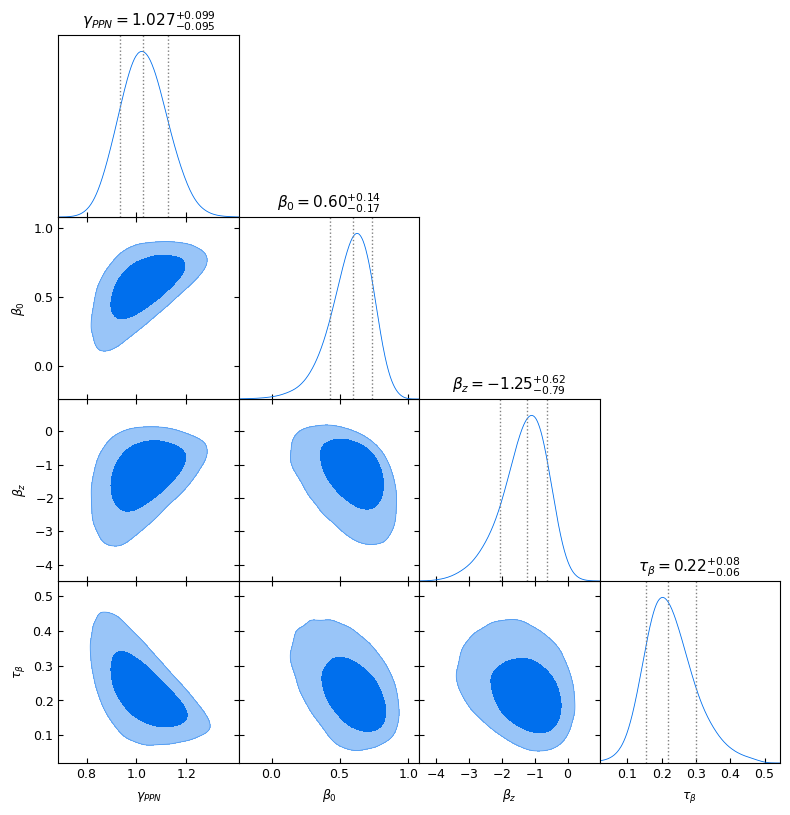

In [5]:
%matplotlib inline
# --- 5. Plotting with getdist ---  
print("\nGenerating triangle plot with getdist...")  
g = plots.GetDistPlotter()  

# Set plot styles, such as line width, etc. 
g.settings.axes_labelsize = 12  
g.settings.axes_fontsize = 12  
g.settings.legend_fontsize = 12  
#g.settings.title_limit_fontsize = 12  

params=['par1', 'par2', 'par3', 'par4']

# Plot the triangle plot (corner plot)  
g.triangle_plot(  
    [mcsamples],      # Pass a list of MCSamples objects for comparison  
    params=params,
    filled=True,     # Fill 2D contour plots   
    #shaded=True,
    contour_colors=["#006fed"],#['tomato'],#
    show_titles=True,
    title_limit=0,
)  

# #for i, name in enumerate(param_names):
for i in range(len(params)):
    ax = g.subplots[i, i]
    #mcmc = np.percentile(samples[:, i], [16, 50, 84]) 
    ci_lower = perc[i][0]
    ci_median = perc[i][1]
    ci_upper = perc[i][2]
    ax.axvline(ci_lower, color='gray', ls=':', lw=1)#, ymax=0.1)
    ax.axvline(ci_median, color='gray', ls=':', lw=1)#, ymax=0.1)
    ax.axvline(ci_upper, color='gray', ls=':', lw=1)#;, ymax=0.1)
    #The vertical lines show the 16th, 50th, and 84th percentiles
    ax.set_title(txt[i], fontsize=11)

# We start the loop from i=1 because the first parameter (i=0) only appears 
# as an X-axis and has no corresponding Y-axis to modify.
for i in range(1, len(params)):
    x_axis_subplot = g.subplots[i, i]  
    y_axis_subplot = g.subplots[i, 0]
    
    # Get the limits and ticks from the source X-axis.
    x_lims = x_axis_subplot.get_xlim()
    x_ticks = x_axis_subplot.get_xticks()
    
    # This print statement is for verification purposes.
    # print(f"Parameter '{names[i]}': Got limits {x_lims} and ticks {x_ticks} from its X-axis.")
    # Apply these limits and ticks to the corresponding Y-axis.
    y_axis_subplot.set_ylim(x_lims)
    y_axis_subplot.set_yticks(x_ticks)

#plt.tight_layout()
plt.savefig('img_mcmc_main.pdf', dpi=400, bbox_inches='tight')
#plt.savefig('img_mcmc_main.png', dpi=400, bbox_inches='tight')
plt.show()